In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img_path = f"etc/engr.jpeg"
img = cv2.imread(img_path)

In [3]:
def display_img(img):
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

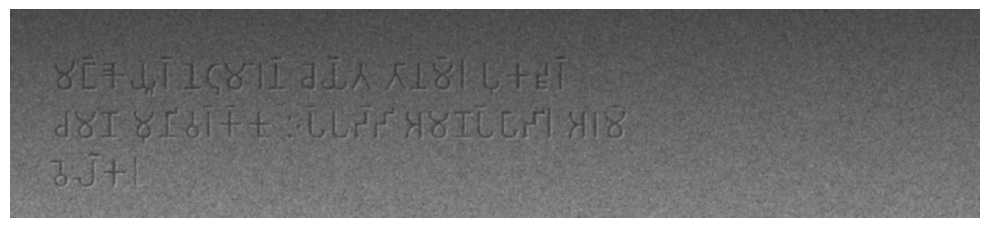

In [4]:
display_img(img)

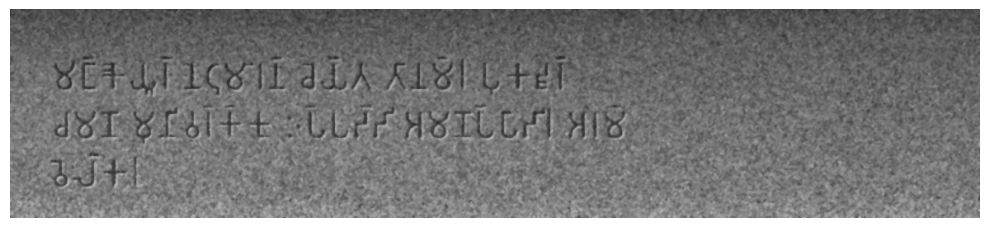

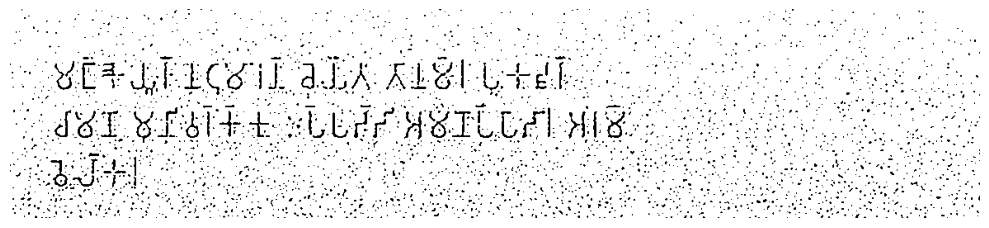

In [103]:
# Binarize the already-loaded BGR image `img`
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))
enhanced = clahe.apply(gray)
# blur = cv2.GaussianBlur(enhanced, (3,3), 0)
blur = cv2.medianBlur(enhanced, 3)
# _, bin_img = cv2.threshold(blur, 128, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
bin_img = cv2.adaptiveThreshold(
    enhanced,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    7,
    10
)

blurred = cv2.medianBlur(bin_img, 3)

# Convert to BGR for display and show
bin_bgr = cv2.cvtColor(blurred, cv2.COLOR_GRAY2BGR)
display_img(blur)
display_img(bin_bgr)

In [6]:
def preprocess_for_ocr(image_path, output_path=None):
    # 1. Load Image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image at {image_path}")

    # 2. Denoise (Targeting the 'grit' / salt-and-pepper noise)
    # Median blur is excellent for removing salt-and-pepper noise while preserving edges.
    # Kernel size 3 or 5 depending on resolution.
    denoised = cv2.medianBlur(img, 3)

    # 3. Enhance Contrast (Targeting 'uneven_lighting' and weak 'engraving_effect')
    # CLAHE creates local contrast enhancement, countering the gradient lighting overlay.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(denoised)

    # 4. Binarization (Targeting stone texture variation)
    # Standard Otsu's thresholding often fails with stone textures because the
    # background variations (noise clumps) are interpreted as objects.
    # Adaptive thresholding calculates the threshold for small regions locally.
    binary = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=31,  # Size of the neighborhood (must be odd)
        C=10           # Constant subtracted from mean (fine-tune this for 'grit' sensitivity)
    )

    # 5. Noise Cleanup (Morphological Operations)
    # The stone texture will likely leave small black specks after thresholding.
    # We use 'Opening' (Erosion followed by Dilation) to remove small noise.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    
    # Note: In your generation, text is 'carved' (dark). 
    # Adaptive Threshold normally results in Black Text on White BG.
    # If the output looks inverted (White text on black), uncomment the bitwise_not.
    # binary = cv2.bitwise_not(binary) 

    clean_mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    
    # Optional: Dilate slightly if the synthesis 'erosion' made text too thin for OCR
    # dilation_kernel = np.ones((2,2), np.uint8)
    # clean_mask = cv2.erode(clean_mask, dilation_kernel, iterations=1) # Erode darkens (thickens) black text on white bg

    # Display or Save
    if output_path:
        cv2.imwrite(output_path, clean_mask)
        print(f"Preprocessed image saved to {output_path}")
    
    return clean_mask

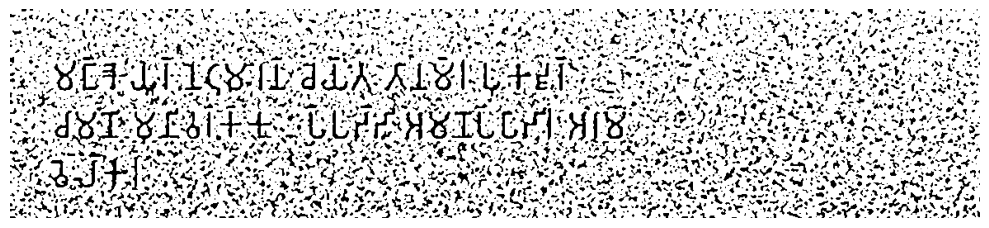

In [9]:
display_img(preprocess_for_ocr(img_path))